# Lab 7: Great British Bake Off (A/B Test)

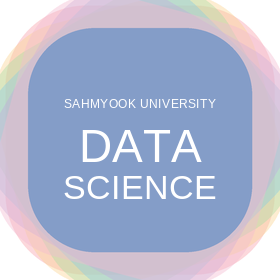

Welcome to Lab 7! This week's lab will focus on A/B Testing using data from the popular British television show, [*The Great British Bake Off*](https://en.wikipedia.org/wiki/The_Great_British_Bake_Off).

## **Helpful Resource:**
- [Python Reference](http://data8.org/sp26/reference/)

**Recommended Readings:**

* [Error Probabilities](https://inferentialthinking.com/chapters/11/4/Error_Probabilities.html)
* [A/B Testing](https://inferentialthinking.com/chapters/12/1/AB_Testing.html)

In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/lab/lab07')
os.makedirs('tests', exist_ok=True)
with open('lab07.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('lab07.ipynb')
print('Ready! (9 tests loaded)')

**Submission**: When you're finished, run every cell and check that the tests pass, then download the notebook with **File → Download → Download .ipynb** and upload it to the LMS.

Let's begin by setting up the tests and imports by running the cell below.

In [ ]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 0. Mid-Semester Survey

We would like you to fill out the mid-semester survey before proceeding any further in this assignment.

Please fill out the survey below and input the secret phrase that is shown at the end of the form when you submit. Please assign this phrase to `mid_secret` as a string in the cell below!

Find the survey [in the course survey form](https://docs.google.com/forms/d/e/1FAIpQLScpcSK2MHTeZK8DtBmapfPezTp6JoKjeQvcDZIOzpYN-wdV-A/viewform?usp=dialog).

In [ ]:
mid_secret = ...

In [ ]:
grader.check("q0")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 1. A/B Testing

A/B testing is a form of hypothesis testing that allows you to make comparisons between two distributions — distribution of group “A” and distribution of group “B”. We may also refer to an A/B test as a permutation test.

You'll almost never be explicitly asked to perform an A/B test. Make sure you can identify situations where the test is appropriate and know how to correctly implement each step. Oftentimes, we use an A/B test to determine whether or not two samples came from the same underlying distribution.

<hr style="border: 1px solid #7a98c7;" />

**Question 1.1.** The following statements are the steps of an A/B hypothesis test presented in a *random order*:

1. Choose a test statistic (typically the difference in means between two categories)

2. Shuffle the labels of the original sample, find your simulated test statistic, and repeat many times

3. Find the value of the observed test statistic

4. Calculate the p-value based off your observed and simulated test statistics

5. Define a null and alternate hypothesis

6. Use the p-value and p-value cutoff to draw a conclusion about the null hypothesis

Assign `ab_test_order` to an array of integers that contains the correct order of an A/B test, where the first item of the array is the first step of an A/B test and the last item of the array is the last step of an A/B test.


In [ ]:
ab_test_order = ...

In [ ]:
grader.check("q1_1")

<!-- BEGIN QUESTION -->

<hr style="border: 1px solid #7a98c7;" />

**Question 1.2.** If the null hypothesis of an A/B test is correct, should the order of labels affect the differences in means between each group? Why do we shuffle labels in an A/B test? If you are in a lab section, confirm your answer with a neighbor or staff member before moving on. 


_Type your answer here, replacing this text._

<!-- END QUESTION -->

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 2. The Great British Bake Off

>"The Great British Bake Off (often abbreviated to Bake Off or GBBO) is a British television baking competition, produced by Love Productions, in which a group of amateur bakers compete against each other in a series of rounds, attempting to impress a group of judges with their baking skills" [Wikipedia](https://en.wikipedia.org/wiki/The_Great_British_Bake_Off)

For every week of the competition, the judges assign one contestant the title "Star Baker". Ultimately, one winner is crowned every season. Using this information, we would like to investigate how winning Star Baker awards affects the odds of winning a season of the show.

<!-- BEGIN QUESTION -->

<hr style="border: 1px solid #7a98c7;" />

**Question 2.1.** We want to know whether winning more Star Baker awards ___causes___ an increase in likelihood of winning a season.  Why is it not sufficient to compare star baker rates for winners and losers?


_Type your answer here, replacing this text._

<!-- END QUESTION -->

<hr style="border: 1px solid #7a98c7;" />

#### Running an Experiment

We are going to run the following hypothesis test to determine the association between winning and number of Star Baker awards. The population we are examining is every contestant from seasons 2 through 11 of GBBO. We are going to use the following null and alternative hypotheses:

**Null hypothesis:** The distribution of Star Baker awards between contestants who won their season and contestants who did not win their season is the same.

**Alternative hypothesis:** Contestants who win their season of the show will win more Star Baker awards on average.

Our alternative hypothesis is related to our suspicion that contestants who win more Star Baker awards are more skilled, so they are more likely to win the season.

<!-- BEGIN QUESTION -->

---

**Question 2.2.** Why is it appropriate to use an A/B test to test this hypothesis? What is the “A” group and what is the “B” group? 


_Type your answer here, replacing this text._

<!-- END QUESTION -->

Check your answers with your neighbors or a staff member before you move on to the next section.

The `bakers` table below describes the number of star baker awards each contest won and whether or not they won their season (`1` if they won, `0` if they did not win). The data was manually aggregated from Wikipedia for seasons 2-11 of the show. We randomized the order of rows as to not spoil the outcome of the show.

In [ ]:
bakers = Table.read_table("star_bakers.csv")
bakers.show(3)

<hr style="border: 1px solid #7a98c7;" />

**Question 2.3.** Visualize the distribution of Star Baker awards for winners and non-winners as overlaid histograms. You should use the bins we provided.

Hint: You will want to use the group argument of `tbl.hist`. In order to produce several overlayed histograms based on unique values in a given column, we can do something like `tbl.hist(..., group=<col_name>, bins=...)`. This will graph one histogram for each unique value in the specified column all on a single plot.


In [ ]:
useful_bins = np.arange(0, 7) # Do not delete!

In [ ]:
...

<hr style="border: 1px solid #7a98c7;" />

**Question 2.4.** We want to figure out if there is a difference between the distribution of Star Baker awards between winners and non winners. 

What should the test statistic be? Which values of this test statistic support the null, and which values support the alternative? **Assign `test_option` to the number corresponding to the correct test statistic.**

1. Absolute value of the difference between the means between both groups; high values support the null
2. Absolute value of the difference between the means between both groups; low values support the null
3. Average Star Baker awards for winners - average Star Baker awards for non-winners; high values support the null
4. Average Star Baker awards for winners - average Star Baker awards for non-winners; low values support the null

Before moving on, confirm your answer with a peer or in the discussion forums.

_Hint:_ You should think about what measures we use to describe a distribution. 


In [ ]:
test_option = ...

In [ ]:
grader.check("q2_4")

<hr style="border: 1px solid #7a98c7;" />

**Question 2.5.** Create a new table called `means` that contains the mean number of star baker awards for bakers who did not win (`won==0`) and bakers that did win (`won==1`). The table should have the column names `won` and `star baker awards mean`.

In [ ]:
means = ...
means

In [ ]:
grader.check("q2_5")

<hr style="border: 1px solid #7a98c7;" />

**Question 2.6.** Set `observed_difference` to the observed test statistic using the `means` table. 


In [ ]:
observed_difference = ...
observed_difference

In [ ]:
grader.check("q2_6")

<hr style="border: 1px solid #7a98c7;" />

**Question 2.7.** Given a table `tbl` (like `bakers`), a label column `label_col`, and a values column `val_col`, write a function that calculates the appropriate test statistic.

*Hint:* Inside the function, you will most likely want to make a **new** `means` table based on the function's arguments. **However, avoid using the original `means` table itself,** since this assumes you will always use the same `bakers` table.

*Hint:* Make sure that you are taking the directionality of our alternative hypothesis into account.


In [ ]:
def find_test_stat(tbl, label_col, val_col):
    ...

find_test_stat(bakers, "won", "star baker awards")

In [ ]:
grader.check("q2_7")

When we run a simulation for A/B testing, we resample by **shuffling the labels** of the original sample. If the null hypothesis is true and the star baker award distributions are the same, we expect that the difference in mean star baker awards to not change when `"won"` labels are changed.

<hr style="border: 1px solid #7a98c7;" />

**Question 2.8.** Write a function `simulate_and_test_statistic` to compute one trial of our A/B test. Your function should run a simulation and return a test statistic.

*Hint:* Textbook chapter [12.1.4](https://inferentialthinking.com/chapters/12/1/AB_Testing.html#predicting-the-statistic-under-the-null-hypothesis) can help!

In [ ]:
def simulate_and_test_statistic(tbl, labels_col, values_col):
    ...

simulate_and_test_statistic(bakers, "won", "star baker awards")

In [ ]:
grader.check("q2_8")

<hr style="border: 1px solid #7a98c7;" />

**Question 2.9.** Simulate 5000 trials of our A/B test and store the test statistics in an array called `differences`.


In [ ]:
# This cell might take a couple seconds to run
differences = make_array()

...
                                                 
differences

In [ ]:
grader.check("q2_9")

Run the cell below to view a histogram of your simulated test statistics plotted with your observed test statistic as a red dot.

In [ ]:
Table().with_column('Difference Between Group Means', differences).hist(bins=20)
plots.scatter(observed_difference, 0, color='red', s=30, zorder=2)
plots.ylim(-0.1, 1.35);

<hr style="border: 1px solid #7a98c7;" />

**Question 2.10.** Find the p-value for your test and assign it to `empirical_p`.


In [ ]:
empirical_p = ...
empirical_p

In [ ]:
grader.check("q2_10")

<!-- BEGIN QUESTION -->

<hr style="border: 1px solid #7a98c7;" />

**Question 2.11.** Using a 5% p-value cutoff, draw a conclusion about the null and alternative hypotheses. Describe your findings using simple, non-technical language. What does your analysis tell you about the association between star baker awards and winning? What can you claim about causation from your statistical analysis? Confirm your answer with a peer, instructor or in the discussion forums. 

*Hint:* See section [12.1.6](https://inferentialthinking.com/chapters/12/1/AB_Testing.html#conclusion-of-the-test)


_Type your answer here, replacing this text._

<!-- END QUESTION -->

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />


---

You're done with lab!

**Important submission steps:**
1. Run all the cells and verify that every test passes.
2. Choose **File → Download → Download .ipynb**.
3. Upload the `.ipynb` file to the LMS.

**Make sure every cell has been run before you download — the outputs are part of what you hand in.**


### Pets of this data science course

Suki and Sandie hope you had fun doing this lab!

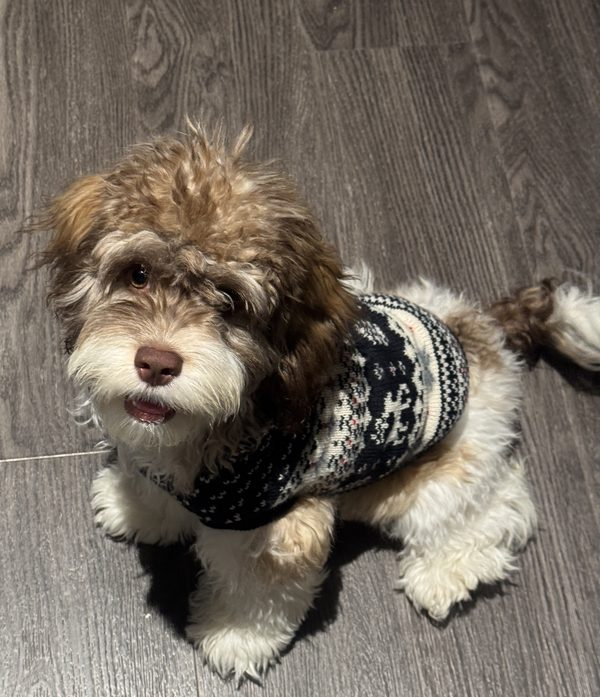
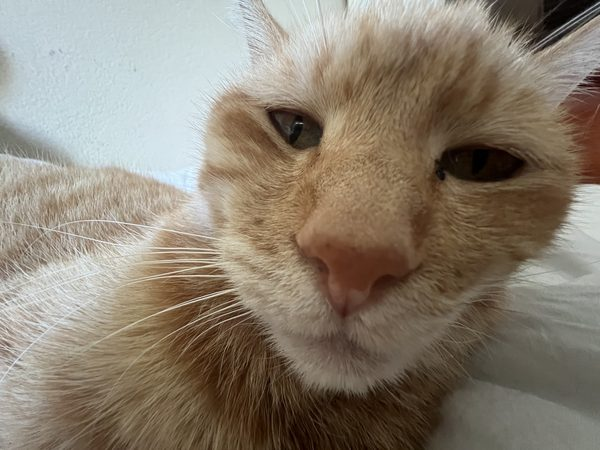

Congrats on completing Lab 7!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_